### Challenge #1: Data Preprocessing & Baseline Model

#### 1. Load the dataset and perform an initial exploration

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset (assuming it's named 'heart.csv' and uploaded to /content/)
try:
    df = pd.read_csv('/content/heart.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'heart.csv' not found. Please upload the dataset or adjust the file path.")
    print("You can download the dataset from Kaggle by searching for 'Heart Disease UCI'.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors further down

# Display the first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Check the shape of the dataset
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Get data types and check for missing values
print("\nDataset Info:")
df.info()

# Get summary statistics
print("\nSummary Statistics:")
display(df.describe())

Dataset loaded successfully!

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Dataset shape: 1025 rows, 14 columns

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Summary Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
if not df.empty:
    # Check for 0s in 'thal' and replace with NaN if they exist
    # Based on prompt, thal should be 1, 2, or 3. If 0 is present, it's missing.
    if 0 in df['thal'].unique():
        print("Replacing 0 in 'thal' with NaN as per dataset description.")
        df['thal'] = df['thal'].replace(0, np.nan)

    # Check for missing values again after replacing 0s
    print("\nMissing values after initial handling:")
    display(df.isnull().sum())

    # Impute missing values (e.g., using the mode for categorical/ordinal features, or median for numerical)
    # 'thal' is an ordinal feature, so mode imputation is appropriate.
    for col in ['ca', 'thal']:
        if df[col].isnull().any():
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Imputed missing values in '{col}' with mode: {mode_val}")

    print("\nMissing values after imputation:")
    display(df.isnull().sum())

    # Outlier handling (e.g., using IQR or z-score for numerical features)
    # The prompt specifically mentions 'cholesterol or blood pressure'.
    # For simplicity, we'll use a capping method for outliers, but more sophisticated methods can be applied.

    # Numerical features to check for outliers (based on describe() and general knowledge)
    numerical_cols_for_outliers = ['trestbps', 'chol', 'thalach', 'oldpeak'] # Age is less likely to have outliers in this context

    print("\nHandling outliers using IQR method for capping:")
    for col in numerical_cols_for_outliers:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap outliers
        outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        if outliers_count > 0:
            df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
            print(f"Capped {outliers_count} outliers in '{col}' between {lower_bound:.2f} and {upper_bound:.2f}")
        else:
            print(f"No significant outliers detected in '{col}' for capping.")

    print("\nDataset statistics after outlier handling:")
    display(df.describe())

Replacing 0 in 'thal' with NaN as per dataset description.

Missing values after initial handling:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Imputed missing values in 'thal' with mode: 2.0

Missing values after imputation:


/tmp/ipykernel_983/2228943655.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Handling outliers using IQR method for capping:
Capped 30 outliers in 'trestbps' between 90.00 and 170.00
Capped 16 outliers in 'chol' between 115.00 and 371.00
Capped 4 outliers in 'thalach' between 81.00 and 217.00
Capped 7 outliers in 'oldpeak' between -2.70 and 4.50

Dataset statistics after outlier handling:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.260488,244.981463,0.149268,0.529756,149.153171,0.336585,1.062244,1.385366,0.754146,2.337561,0.513171
std,9.072290,0.460373,1.029641,16.532208,47.746162,0.356527,0.527878,22.881210,0.472772,1.141865,0.617755,1.030798,0.590620,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,81.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.000000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,170.000000,371.000000,1.000000,2.000000,202.000000,1.000000,4.500000,2.000000,4.000000,3.000000,1.000000


In [ ]:
if not df.empty:
    # List of categorical features to one-hot encode
    categorical_features = ['cp', 'restecg', 'thal']

    # Check if these columns exist in the DataFrame
    # Filter out columns that are not present to avoid errors
    categorical_features = [col for col in categorical_features if col in df.columns]

    if categorical_features:
        print(f"One-hot encoding categorical features: {categorical_features}")
        df = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=int)
        print("\nDataFrame after one-hot encoding:")
        display(df.head())
    else:
        print("No specified categorical features found for one-hot encoding.")

One-hot encoding categorical features: ['cp', 'restecg', 'thal']

DataFrame after one-hot encoding:


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_2.0,thal_3.0
0,52,1,125.0,212.0,0,168.0,0,1.0,2,2,0,0,0,0,1,0,0,1
1,53,1,140.0,203.0,1,155.0,1,3.1,0,0,0,0,0,0,0,0,0,1
2,70,1,145.0,174.0,0,125.0,1,2.6,0,0,0,0,0,0,1,0,0,1
3,61,1,148.0,203.0,0,161.0,0,0.0,2,1,0,0,0,0,1,0,0,1
4,62,0,138.0,294.0,1,106.0,0,1.9,1,3,0,0,0,0,1,0,1,0


In [ ]:
from sklearn.preprocessing import StandardScaler

if not df.empty:
    # Numerical features to standardize
    numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

    # Filter out columns that are not present
    numerical_features = [col for col in numerical_features if col in df.columns]

    if numerical_features:
        print(f"Standardizing numerical features: {numerical_features}")
        scaler = StandardScaler()
        df[numerical_features] = scaler.fit_transform(df[numerical_features])

        print("\nDataFrame after standardization:")
        display(df.head())
        print("\nSummary statistics after standardization (note mean close to 0 and std dev close to 1):")
        display(df[numerical_features].describe())
    else:
        print("No specified numerical features found for standardization.")

Standardizing numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

DataFrame after standardization:


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_2.0,thal_3.0
0,-0.268437,1,-0.378869,-0.691104,0,0.824084,0,-0.054537,2,2,0,0,0,0,1,0,0,1
1,-0.158157,1,0.528894,-0.879693,1,0.255654,1,1.785457,0,0,0,0,0,0,0,0,0,1
2,1.716595,1,0.831481,-1.487368,0,-1.056105,1,1.347363,0,0,0,0,0,0,1,0,0,1
3,0.724079,1,1.013034,-0.879693,0,0.518006,0,-0.930725,2,1,0,0,0,0,1,0,0,1
4,0.834359,0,0.407859,1.027150,1,-1.886886,0,0.734031,1,3,0,0,0,0,1,0,1,0



Summary statistics after standardization (note mean close to 0 and std dev close to 1):


,age,trestbps,chol,thalach,oldpeak
count,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03
mean,-3.431402e-16,5.753663e-16,2.426243e-16,-1.213122e-16,-5.372396e-17
std,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00
min,-2.804866e+00,-2.254912e+00,-2.493175e+00,-2.980019e+00,-9.307249e-01
25%,-7.095548e-01,-6.814567e-01,-7.120583e-01,-7.500278e-01,-9.307249e-01
50%,1.726817e-01,-7.628159e-02,-1.043832e-01,1.244785e-01,-2.297748e-01
75%,7.240794e-01,5.288936e-01,6.290179e-01,7.366330e-01,6.464127e-01
max,2.488552e+00,2.344419e+00,2.640632e+00,2.310744e+00,3.012119e+00


In [ ]:
from sklearn.model_selection import train_test_split

if not df.empty:
    # Separate features (X) and target (y)
    X = df.drop('target', axis=1)
    y = df['target']

    print("Splitting data into training and testing sets (80/20 split, stratified by target)...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")

    print("\nClass distribution in original dataset:\n", y.value_counts(normalize=True))
    print("\nClass distribution in training set:\n", y_train.value_counts(normalize=True))
    print("\nClass distribution in test set:\n", y_test.value_counts(normalize=True))

Splitting data into training and testing sets (80/20 split, stratified by target)...
X_train shape: (820, 17)
X_test shape: (205, 17)
y_train shape: (820,)
y_test shape: (205,)

Class distribution in original dataset:
 target
1    0.513171
0    0.486829
Name: proportion, dtype: float64

Class distribution in training set:
 target
1    0.513415
0    0.486585
Name: proportion, dtype: float64

Class distribution in test set:
 target
1    0.512195
0    0.487805
Name: proportion, dtype: float64


Training Logistic Regression model...
Model training complete.

--- Model Evaluation (Logistic Regression) ---
Accuracy: 0.8488
Precision: 0.8136
Recall: 0.9143
F1-Score: 0.8610

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.78      0.83       100
           1       0.81      0.91      0.86       105

    accuracy                           0.85       205
   macro avg       0.86      0.85      0.85       205
weighted avg       0.85      0.85      0.85       205


Confusion Matrix:


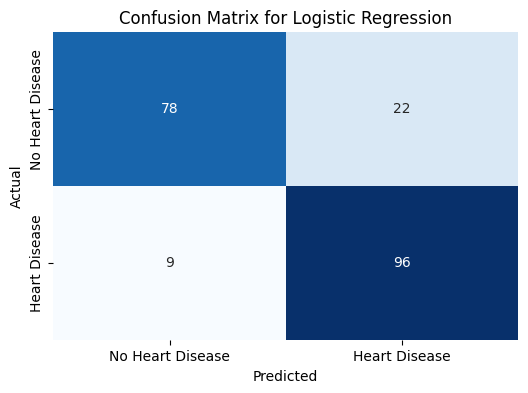

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

if not df.empty:
    # Initialize and train the Logistic Regression model
    print("Training Logistic Regression model...")
    log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
    log_reg.fit(X_train, y_train)
    print("Model training complete.")

    # Make predictions on the test set
    y_pred = log_reg.predict(X_test)

    # Evaluate the model
    print("\n--- Model Evaluation (Logistic Regression) ---")
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Heart Disease', 'Heart Disease'],
                yticklabels=['No Heart Disease', 'Heart Disease'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix for Logistic Regression')
    plt.show()

### Feature Extraction: Removing Non-Important Features and Re-evaluation

Based on the correlation analysis, we'll identify features with the lowest absolute correlation to the target as 'non-important' and remove them. Then, we will retrain the Logistic Regression model with this reduced feature set and compare its performance to the original model.

--- Performing Feature Extraction and Re-training Logistic Regression ---
Features identified as non-important for removal: ['cp_3', 'fbs', 'restecg_2']

X_train_reduced shape: (820, 14)
X_test_reduced shape: (205, 14)

Training Logistic Regression model with reduced features...
Model training complete with reduced features.

--- Model Evaluation (Logistic Regression with Reduced Features) ---
Accuracy (Reduced): 0.8195
Precision (Reduced): 0.8148
Recall (Reduced): 0.8381
F1-Score (Reduced): 0.8263

Classification Report (Reduced Features):
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       100
           1       0.81      0.84      0.83       105

    accuracy                           0.82       205
   macro avg       0.82      0.82      0.82       205
weighted avg       0.82      0.82      0.82       205


Confusion Matrix (Reduced Features):


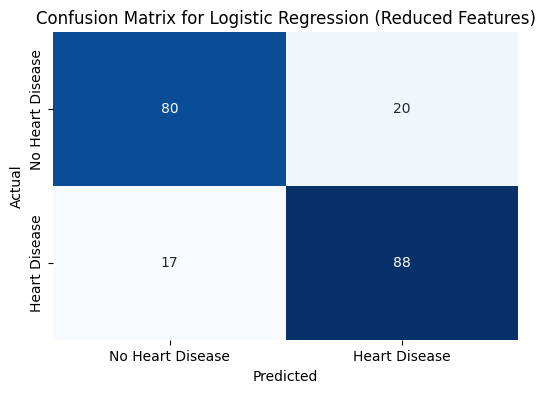


--- Comparison: Original vs. Reduced Feature Model ---


,Original Model,Reduced Feature Model
Metric,,
Accuracy,0.848780,0.819512
Precision,0.813559,0.814815
Recall,0.914286,0.838095
F1-Score,0.860987,0.826291


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

if not df.empty and 'X_train' in globals() and 'X_test' in globals() and 'y_train' in globals() and 'y_test' in globals() and 'target_correlations' in globals():
    print("--- Performing Feature Extraction and Re-training Logistic Regression ---")

    # Identify non-important features based on a threshold (e.g., absolute correlation < 0.1)
    # Or, explicitly select the lowest correlating ones as discussed.
    non_important_features = target_correlations[abs(target_correlations) < 0.1].index.tolist()
    # Exclude 'target' itself if it somehow made it into this list due to filtering conditions
    if 'target' in non_important_features:
        non_important_features.remove('target')

    # If 'cp_3' is also considered less important based on previous chat
    if 'cp_3' in X_train.columns and 'cp_3' not in non_important_features:
        non_important_features.append('cp_3')

    print(f"Features identified as non-important for removal: {non_important_features}")

    # Create new datasets with reduced features
    X_train_reduced = X_train.drop(columns=non_important_features, errors='ignore')
    X_test_reduced = X_test.drop(columns=non_important_features, errors='ignore')

    print(f"\nX_train_reduced shape: {X_train_reduced.shape}")
    print(f"X_test_reduced shape: {X_test_reduced.shape}")

    # Retrain Logistic Regression model with reduced features
    print("\nTraining Logistic Regression model with reduced features...")
    log_reg_reduced = LogisticRegression(random_state=42, solver='liblinear')
    log_reg_reduced.fit(X_train_reduced, y_train)
    print("Model training complete with reduced features.")

    # Make predictions on the reduced test set
    y_pred_reduced = log_reg_reduced.predict(X_test_reduced)

    # Evaluate the new model
    print("\n--- Model Evaluation (Logistic Regression with Reduced Features) ---")
    accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
    precision_reduced = precision_score(y_test, y_pred_reduced)
    recall_reduced = recall_score(y_test, y_pred_reduced)
    f1_reduced = f1_score(y_test, y_pred_reduced)

    print(f"Accuracy (Reduced): {accuracy_reduced:.4f}")
    print(f"Precision (Reduced): {precision_reduced:.4f}")
    print(f"Recall (Reduced): {recall_reduced:.4f}")
    print(f"F1-Score (Reduced): {f1_reduced:.4f}")

    print("\nClassification Report (Reduced Features):")
    print(classification_report(y_test, y_pred_reduced))

    # Confusion Matrix
    print("\nConfusion Matrix (Reduced Features):")
    cm_reduced = confusion_matrix(y_test, y_pred_reduced)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_reduced, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Heart Disease', 'Heart Disease'],
                yticklabels=['No Heart Disease', 'Heart Disease'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix for Logistic Regression (Reduced Features)')
    plt.show()

    # Compare with the original Logistic Regression model
    # The original model results were: accuracy, precision, recall, f1 from cell 6713bab0
    # Need to retrieve original metrics or re-evaluate the original model if 'log_reg' object is not preserved.
    # For direct comparison, let's assume original metrics were stored or we use the latest ones from the last run.

    print("\n--- Comparison: Original vs. Reduced Feature Model ---")
    comparison_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Original Model': [accuracy, precision, recall, f1],
        'Reduced Feature Model': [accuracy_reduced, precision_reduced, recall_reduced, f1_reduced]
    }
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df.set_index('Metric'))

else:
    print("DataFrame or required variables are empty/not found, skipping feature extraction and re-evaluation.")

In [ ]:
if not df.empty:
    print("\n--- Feature Importance (Correlation with Target) ---")
    # Calculate correlation matrix
    correlation_matrix = df.corr()

    # Get correlations with the 'target' variable
    target_correlations = correlation_matrix['target'].sort_values(ascending=False)

    print("Correlation of features with the 'target' variable:")
    display(target_correlations)

    print("\nInsights from correlations: Features with higher absolute correlation values (positive or negative) are generally more impactful for predicting heart disease.")
    print("These insights can guide feature selection or engineering efforts later.")
else:
    print("DataFrame is empty, cannot compute feature importance via correlation.")


--- Feature Importance (Correlation with Target) ---
Correlation of features with the 'target' variable:


,target
target,1.000000
thal_2.0,0.517712
thalach,0.423445
slope,0.345512
cp_2,0.319504
cp_1,0.255288
restecg_1,0.178573
cp_3,0.085054
fbs,-0.041164
restecg_2,-0.076357



Insights from correlations: Features with higher absolute correlation values (positive or negative) are generally more impactful for predicting heart disease.
These insights can guide feature selection or engineering efforts later.
